# K-means model selection for Beijing PM data

This notebook evaluates K-means on the Beijing PM observations using precipitation, humidity, temperature, dew point, instant wind speed, and pressure.

Instead of fixing $k=3$, it compares several values of $k$ with the elbow method and silhouette score.

In [72]:
#Der unsichbare Schalter
#Frage: GIbt es in Beijing zwei Luft-Realitäten - eine mit, eine ohne Fernwärme?

import pandas as pd

beijing_df = pd.read_csv("BeijingPM20100101_20151231.csv")
# Keep only observations at hour 12
#beijing_df = beijing_df[beijing_df["hour"] == 12]

weather_df = (
    beijing_df[["precipitation", "HUMI", "TEMP", "DEWP", "Iws", "PRES"]]
    .dropna()
    .rename(
        columns={
            "HUMI": "humidity",
            "TEMP": "temperature",
            "DEWP": "dew_point",
            "Iws": "instant_wind_speed",
            "PRES": "pressure",
        }
    )
    .copy()
)
weather_df.head()
weather_df.info()

<class 'pandas.DataFrame'>
Index: 51765 entries, 0 to 52583
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   precipitation       51765 non-null  float64
 1   humidity            51765 non-null  float64
 2   temperature         51765 non-null  float64
 3   dew_point           51765 non-null  float64
 4   instant_wind_speed  51765 non-null  float64
 5   pressure            51765 non-null  float64
dtypes: float64(6)
memory usage: 2.8 MB


<class 'pandas.DataFrame'>
RangeIndex: 52584 entries, 0 to 52583
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   No               52584 non-null  int64  
 1   year             52584 non-null  int64  
 2   month            52584 non-null  int64  
 3   day              52584 non-null  int64  
 4   hour             52584 non-null  int64  
 5   season           52584 non-null  int64  
 6   PM_Dongsi        25052 non-null  float64
 7   PM_Dongsihuan    20508 non-null  float64
 8   PM_Nongzhanguan  24931 non-null  float64
 9   PM_US Post       50387 non-null  float64
 10  DEWP             52579 non-null  float64
 11  HUMI             52245 non-null  float64
 12  PRES             52245 non-null  float64
 13  TEMP             52579 non-null  float64
 14  cbwd             52579 non-null  str    
 15  Iws              52579 non-null  float64
 16  precipitation    52100 non-null  float64
 17  Iprec            52100 

<Axes: title={'center': 'PM2.5 in Beijing 2014'}, xlabel='date'>

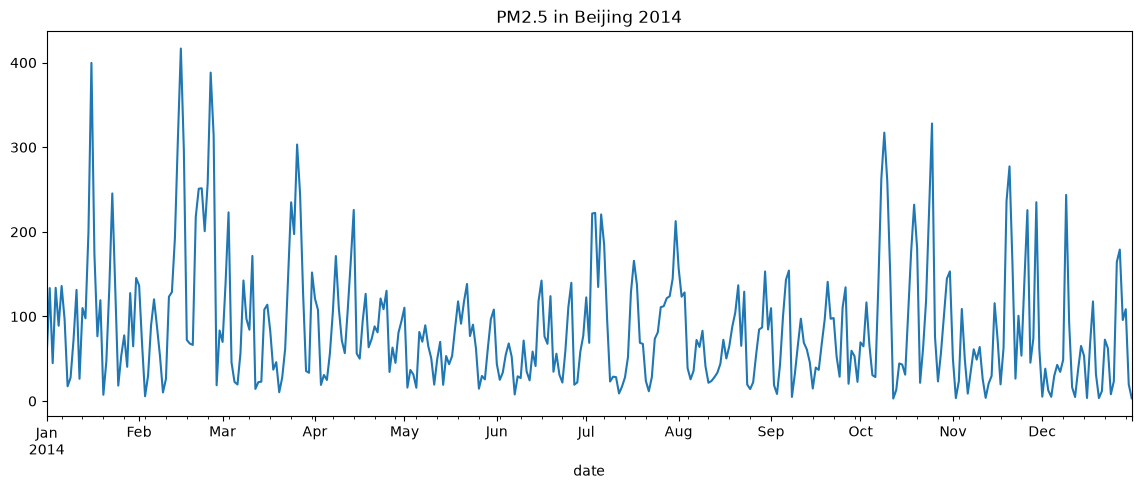

In [73]:
beijing_df.head()
beijing_df.info()
beijing_df=beijing_df[beijing_df['year']==2014].copy()
beijing_df=beijing_df[["PM_Dongsi","year","month","day","hour"]]
beijing_df['date']= pd.to_datetime(beijing_df[['year','month','day','hour']])
beijing_df.head()
beijing_df = beijing_df.set_index('date')
daily_pm_2014 = beijing_df['PM_Dongsi'].resample('D').mean()
daily_pm_2014.plot(figsize=(14,5), title='PM2.5 in Beijing 2014')

In [74]:
# =============================================================================
# STEP 1 — Data Ingestion & Cleaning
# Owner: Danish
# Dataset: PM2.5 Data of Five Chinese Cities (UCI ML Repository)
# Coverage: hourly observations, 2010-01-01 → 2015-12-31
#
# Selective PDF-recommendation version
# ─────────────────────────────────────────────────────────────────────────────
# Incorporated here:
#   1) Do NOT treat missing precipitation as "dry hour" / 0.0.
#      Precipitation is retained for diagnostics but excluded from the main model.
#   2) Avoid unlimited PM target imputation. Only one-hour PM gaps are forward-filled.
#      Remaining missing PM rows are dropped.
#   3) Preserve circular wind direction via wind_sin and wind_cos, when cbwd exists.
#
# Deliberately NOT changed here:
#   • PM station columns are still averaged to city-hour PM for comparability with
#     the original notebook. A station-level refactor is better as a separate
#     robustness/extension notebook because it changes the unit of analysis.
# =============================================================================

import os
import pandas as pd
import numpy as np

# ── 1. File map ───────────────────────────────────────────────────────────────
# Place the five raw CSVs in the same directory as this notebook.
FILE_MAP = {
    "Beijing":   "BeijingPM20100101_20151231.csv",
    "Shanghai":  "ShanghaiPM20100101_20151231.csv",
    "Guangzhou": "GuangzhouPM20100101_20151231.csv",
    "Chengdu":   "ChengduPM20100101_20151231.csv",
    "Shenyang":  "ShenyangPM20100101_20151231.csv",
}

# Structural columns shared across all five datasets.
# cbwd = combined wind direction, used to create wind_sin/wind_cos.
# precipitation is retained only for diagnostics because it is absent / missing in
# some city files and should NOT be imputed to 0.0.
CORE_COLS = ["city", "year", "month", "day", "hour", "season",
             "PM", "TEMP", "PRES", "HUMI", "DEWP", "Iws", "cbwd", "precipitation"]

# Main model features available immediately after Step 1.
# Precipitation is intentionally excluded from the main model. If you later add
# reliable precipitation data for all cities, add it back as a robustness model.
# YEAH, NO WE HAVE TO INCLUDE PRECIPITATION, or do we? Google says no!
WEATHER_FEATURES = ["TEMP", "PRES", "HUMI", "DEWP", "Iws", "boundary_layer_height (m)", "cloud_cover (%)"]
WIND_FEATURES = ["wind_sin", "wind_cos", "wind_dir_missing"]
WIND_DIRECTION = ["wind_sin", "wind_cos"]

# ── 2. Heating-regime definition ──────────────────────────────────────────────
# Treatment variable (causal block): binary indicator that equals 1 when
# the city is inside the government-mandated northern heating zone AND the
# calendar month falls within the active heating season (November–March).

HEATING_CITIES  = {"Beijing", "Shenyang"}
HEATING_MONTHS  = {11, 12, 1, 2, 3}          # Nov–Mar (inclusive)

def engineer_heating_regime(df: pd.DataFrame) -> pd.DataFrame:
    """Add binary `heating_regime` column (treatment variable for causal block)."""
    df = df.copy()
    df["heating_regime"] = (
        df["city"].isin(HEATING_CITIES) & df["month"].isin(HEATING_MONTHS)
    ).astype(int)
    return df

# ── 3. Wind-direction encoding ────────────────────────────────────────────────
# Meteorological convention: North = 0°, East = 90°, South = 180°, West = 270°.
# The UCI files often contain cbwd values such as NE, NW, SE, SW and sometimes
# "cv" (calm/variable). Calm/variable has undefined direction, so we encode both
# sin/cos as 0 and set wind_dir_missing = 1.

WIND_ANGLE_MAP = {
    "N": 0, "NNE": 22.5, "NE": 45, "ENE": 67.5,
    "E": 90, "ESE": 112.5, "SE": 135, "SSE": 157.5,
    "S": 180, "SSW": 202.5, "SW": 225, "WSW": 247.5,
    "W": 270, "WNW": 292.5, "NW": 315, "NNW": 337.5,
}
CALM_OR_VARIABLE = {"CV", "CALM", "VARIABLE", "VAR", "NONE", ""}

def add_wind_direction_features(df: pd.DataFrame) -> pd.DataFrame:
    """Encode cbwd as circular wind_sin/wind_cos plus an undefined-direction flag."""
    df = df.copy()

    if "cbwd" not in df.columns:
        df["cbwd"] = np.nan

    cbwd = df["cbwd"].astype("string").str.strip().str.upper()
    angle = cbwd.map(WIND_ANGLE_MAP).astype(float)

    calm_or_variable = cbwd.isin(CALM_OR_VARIABLE)
    unmapped_or_missing = cbwd.isna() | (angle.isna() & ~calm_or_variable)
    undefined_direction = calm_or_variable | unmapped_or_missing

    theta = np.deg2rad(angle)
    df["wind_sin"] = np.sin(theta)
    df["wind_cos"] = np.cos(theta)

    # Undefined direction: no meaningful direction vector; set vector to zero
    # and let wind_dir_missing tell the model that direction was unavailable.
    df.loc[undefined_direction, ["wind_sin", "wind_cos"]] = 0.0
    df["wind_dir_missing"] = undefined_direction.astype(int)
    df["wind_angle"] = angle

    return df

# ── 4. Ingestion loop & Ersetzung für Beijing ──────────────────────────────────

def load_city(city: str, filename: str) -> pd.DataFrame:
    """Read one city CSV and return a cleaned slice with unified columns."""
    if not os.path.exists(filename):
        raise FileNotFoundError(
            f"Expected '{filename}' in the working directory."
        )

    df = pd.read_csv(filename, na_values=["NA", "NaN", " ", ""])
    df["city"] = city

    pm_cols = [c for c in df.columns if c.upper().startswith("PM_")]
    if not pm_cols:
        raise ValueError(f"No PM_* columns found in {filename}.")
    df["PM"] = df[pm_cols].mean(axis=1)

    for optional_col in ["cbwd", "precipitation"]:
        if optional_col not in df.columns:
            df[optional_col] = np.nan

    available = [c for c in CORE_COLS if c in df.columns]
    df = df[available].copy()
    return df

def replace_city_weather_with_exact_data(df_all_cities: pd.DataFrame, city_name: str, neu_wetter_path: str) -> pd.DataFrame:
    """Ersetzt die ungenauen UCI-Wetterdaten für eine bestimmte Stadt durch die präzisen Open-Meteo-CSV-Daten."""
    print(f"\n── Ersetze {city_name}-Wetterdaten mit hochaufgelösten Daten ────────────────")
    
    # 1. Daten trennen: Nur die spezifische Stadt isolieren
    df_city = df_all_cities[df_all_cities['city'] == city_name].copy()
    df_andere_staedte = df_all_cities[df_all_cities['city'] != city_name].copy()
    
    # Falls keine Daten für diese Stadt existieren, überspringen
    if len(df_city) == 0:
        print(f"  ⚠️  Keine Daten für {city_name} im Datensatz gefunden. Überspringe.")
        return df_all_cities
    
    # 2. Neue Wetterdatei laden (Metadaten-Zeilen überspringen)
    df_wetter_neu = pd.read_csv(neu_wetter_path, skiprows=3)
    
    # Zeitstempel korrekt parsen (ISO-8601 Format mit 'T')
    df_wetter_neu['time'] = pd.to_datetime(df_wetter_neu['time'], format='%Y-%m-%dT%H:%M')
    
    # 3. Synchronisations-Zeitachse für die City-Frame bauen
    df_city['temp_datetime'] = pd.to_datetime(df_city[['year', 'month', 'day', 'hour']])
    
    # 4. Die alten Wetterspalten UND bereits existierende neue Zusatzspalten löschen
    # Das verhindert den Suffix-Konflikt (_x, _y) in den nachfolgenden Schleifendurchläufen!
    alte_wetter_spalten = ['TEMP', 'PRES', 'HUMI', 'DEWP', 'cbwd', 'Iws', 'precipitation']
    
    # Welche Spalten bringt die neue Wetterdatei mit? (nach dem Mapping)
    neue_features_mapped = [
        "wind_direction_10m (°)", "boundary_layer_height (m)",
        "rain (mm)", "snowfall (cm)", "TEMP", "PRES", "HUMI", "DEWP", "Iws", "precipitation", "wind_gusts_10m (km/h)", "cloud_cover (%)"
    ]
    
    # Wir löschen alle alten Wetterspalten UND alle Spalten, die gleich durch das Merge neu reinkommen
    spalten_zu_loeschen = set(alte_wetter_spalten + neue_features_mapped + ["wind_sin", "wind_cos", "wind_dir_missing"])
    
    df_city = df_city.drop(columns=[col for col in spalten_zu_loeschen if col in df_city.columns])
    # 5. Zusammenführen über das exakte Datum
    df_city_neu = pd.merge(
        df_city, 
        df_wetter_neu, 
        left_on='temp_datetime', 
        right_on='time', 
        how='inner'
    ).drop(columns=['temp_datetime', 'time'])  # 'time' wird nicht mehr benötigt
    # 6. Neue Spaltennamen auf das Namensschema Ihres Projekts mappen
    mapping_spalten = {
        "temperature_2m (°C)": "TEMP",
        "pressure_msl (hPa)": "PRES",
        "relative_humidity_2m (%)": "HUMI",
        "dew_point_2m (°C)": "DEWP",
        "wind_speed_10m (km/h)": "Iws",
        "precipitation (mm)": "precipitation"
    }
    df_city_neu = df_city_neu.rename(columns=mapping_spalten)
    
    # 7. Die kontinuierliche Windrichtung (0-360°) nutzen für echtes stufenloses sin/cos
    theta = np.deg2rad(df_city_neu["wind_direction_10m (°)"])
    df_city_neu["wind_sin"] = np.sin(theta)
    df_city_neu["wind_cos"] = np.cos(theta)
    
    # Da wir nun lückenlose Daten haben, setzen wir fehlende Flags auf 0
    df_city_neu["wind_dir_missing"] = 0 
    
    # 8. Zusatzspalten bei den anderen Städten mit NaN auffüllen
    zusatz_features = [c for c in df_city_neu.columns if c not in df_andere_staedte.columns]
    for col in zusatz_features:
        df_andere_staedte[col] = np.nan
        
    # 9. Beide Teile wieder vereinigen
    df_andere_staedte = df_andere_staedte[df_city_neu.columns] # Spaltenreihenfolge synchronisieren
    df_finale_pipeline = pd.concat([df_city_neu, df_andere_staedte], ignore_index=True)
    print(f"  ✅ Erfolgreich eingespielt. {city_name} Zeilen: {len(df_city_neu):,}")
    
    return df_finale_pipeline


# === ECHTE AUSFÜHRUNG DER PIPELINE ===

print("── Ingesting city datasets ──────────────────────────────────────────────")
city_frames = []
for city, filename in FILE_MAP.items():
    frame = load_city(city, filename)
    print(f"  {city:10s}  {len(frame):>7,} raw rows  |  PM cols averaged")
    city_frames.append(frame)

# 1. Alle Rohdaten verketten
df_raw = pd.concat(city_frames, ignore_index=True)

# 2. Heizungs-Regime hinzufügen
df_raw = engineer_heating_regime(df_raw)

# 3. Wind-Features für die restlichen 4 Städte berechnen (falls nötig)
df_raw = add_wind_direction_features(df_raw)

# 4. JETZT: Für JEDE Stadt die Wetterdaten ersetzen
# Erstellen Sie eine Mapping-Liste für Ihre Open-Meteo-Dateien
openmeteo_files = {
    "Beijing": "open-meteo-Beijing.csv",
    "Chengdu": "open-meteo-Chengdu.csv",
    "Guangzhou": "open-meteo-Guangzhou.csv",
    "Shanghai": "open-meteo-Shanghai.csv",
    "Shenyang": "open-meteo-Shenyang.csv"
}

# Für jede Stadt die Wetterdaten ersetzen
for city, filepath in openmeteo_files.items():
    df_raw = replace_city_weather_with_exact_data(df_raw, city, filepath)

print(f"\n  Kombiniert & Ersetzt (raw):  {len(df_raw):>7,} rows × {df_raw.shape[1]} columns")

# ── 5. Temporal ordering ──────────────────────────────────────────────────────
# Sort the full panel chronologically within each city so that forward-fill
# operates strictly along the time axis.

df_raw = (df_raw
          .sort_values(["city", "year", "month", "day", "hour"])
          .reset_index(drop=True))

# =============================================================================
# Sensor anomaly handling: convert hidden -9999.0 error codes to NaN.
# =============================================================================
print("── Processing data quality check: Purging -9999 sensor faults ──────────")
for col in ["HUMI", "DEWP"]:
    if col in df_raw.columns:
        fault_count = (df_raw[col] == -9999.0).sum()
        print(f"  Found {fault_count:,} sensor error records (-9999.0) in column: {col}")
        df_raw[col] = df_raw[col].replace(-9999.0, np.nan)
print("  Purge successful. Anomalies converted to NaN placeholders.\n")

# Capture true raw missingness before PM forward-fill and row dropping.
missing_diagnostic_cols = ["PM"] + WEATHER_FEATURES + ["wind_direction_10m (°)", "precipitation"]
raw_missing_before_handling = (
    df_raw.groupby("city", observed=True)[missing_diagnostic_cols]
    .apply(lambda g: g.isna().sum())
)
precip_nulls_by_city = df_raw.groupby("city", observed=True)["precipitation"].apply(lambda g: g.isna().sum())

# ── 6. Missing-value handling ─────────────────────────────────────────────────
# Selective PDF-response strategy:
#   (a) PM target: allow only one-hour forward fill within each city. This avoids
#       turning long monitor outages into artificial flat PM periods.
#   (b) Weather features: drop rows with missing core weather values.
#   (c) Precipitation: do not impute as zero. Keep for diagnostics, but exclude
#       it from the main model.

print("── Missing-value strategy ───────────────────────────────────────────────")
print("  PM target       : forward-fill within city with limit=1 hour only")
print("  Weather features: drop rows with missing TEMP/PRES/HUMI/DEWP/Iws")
print("  Precipitation   : keep missing as NaN; excluded from main model")

pm_nulls_before = df_raw["PM"].isna().sum()
df_raw["PM"] = df_raw.groupby("city", observed=True)["PM"].ffill(limit=1)
pm_nulls_after = df_raw["PM"].isna().sum()
print(f"  PM missing before limited ffill : {pm_nulls_before:,}")
print(f"  PM missing after limited ffill  : {pm_nulls_after:,}")

# Wind direction is added before dropna so all downstream steps can use it.
#THIS IS OUTDATED AND HAS ALREADY HAPPENED
#df_raw = add_wind_direction_features(df_raw)

#wind_undefined_by_city = df_raw.groupby("city", observed=True)["wind_dir_missing"].sum()
#print("\n── Wind-direction encoding ──────────────────────────────────────────────")
#print("  Created wind_sin, wind_cos, and wind_dir_missing from cbwd")
#print("  Undefined/calm/variable/missing wind-direction rows by city:")
#print(wind_undefined_by_city.to_string())

# Drop rows where model-critical fields remain missing. Precipitation is not in
# this subset because it is not used in the main model.
n_before_drop = len(df_raw)
CRITICAL_MODEL_COLS = ["PM"] + WEATHER_FEATURES + WIND_FEATURES

df_clean = df_raw.dropna(subset=CRITICAL_MODEL_COLS).reset_index(drop=True)
n_dropped = n_before_drop - len(df_clean)
print(f"\n  Rows dropped (PM/weather/wind critical nulls): {n_dropped:,}")
print(f"  Rows retained (clean panel)                 : {len(df_clean):,}")

# ── 7. Treatment variable engineering ────────────────────────────────────────
df_clean = engineer_heating_regime(df_clean)

regime_counts = df_clean.groupby("city", observed=True)["heating_regime"].sum()
print(f"\n── heating_regime summary (treated hours per city) ─────────────────────")
print(regime_counts.to_string())

# ── 8. Data-type enforcement ──────────────────────────────────────────────────
# Categorical city saves memory and speeds groupby operations downstream.
df_clean["city"]    = df_clean["city"].astype("category")
df_clean["season"]  = df_clean["season"].astype("category")

# Ensure temporal integers are native int (not float from merge artefacts)
for col in ["year", "month", "day", "hour"]:
    df_clean[col] = df_clean[col].astype(int)

# ── 9. Sanity checks ──────────────────────────────────────────────────────────
print("\n── Sanity checks ────────────────────────────────────────────────────────")

# (i) Year coverage
print(f"  Year range  : {df_clean['year'].min()} – {df_clean['year'].max()}")

# (ii) No remaining nulls in model-critical columns
null_summary = df_clean[CRITICAL_MODEL_COLS + ["heating_regime"]].isnull().sum()
assert null_summary.sum() == 0, f"Unexpected nulls remaining:\n{null_summary[null_summary > 0]}"
print("  Null check  : PASSED — no missing values in critical model columns")

# (iii) Precipitation may still contain NaNs by design
precip_missing_clean = df_clean["precipitation"].isna().sum()
print(f"  Precip NaNs : {precip_missing_clean:,} retained by design; not used in main model")

# (iv) heating_regime is strictly binary
assert set(df_clean["heating_regime"].unique()).issubset({0, 1}), "heating_regime contains non-binary values"
print("  Binary check: PASSED — heating_regime ∈ {0, 1}")

# (v) All five cities present
assert set(df_clean["city"].cat.categories) == set(FILE_MAP.keys()), "Missing cities in clean panel"
print(f"  Cities      : {sorted(df_clean['city'].cat.categories.tolist())}")

# (vi) PM values are non-negative (physical constraint)
assert (df_clean["PM"] >= 0).all(), "Negative PM2.5 values detected — check source data"
print(f"  PM range    : {df_clean['PM'].min():.1f} – {df_clean['PM'].max():.1f} µg/m³")

# ── 10. Final overview ────────────────────────────────────────────────────────
print("\n── Final dataset ────────────────────────────────────────────────────────")
print(f"  Shape  : {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")
print(f"  Memory : {df_clean.memory_usage(deep=True).sum() / 1e6:.1f} MB\n")

display(df_clean.head())
print("\n── Column dtypes & null counts ──────────────────────────────────────────")
df_clean.info()

print("\n── Descriptive statistics ───────────────────────────────────────────────")
display(df_clean.describe())

# =============================================================================
# STEP 1b — Pre-cleaning diagnostics (raw missingness, coverage, range checks)
# =============================================================================

print("── Pre-cleaning missingness (raw, before limited ffill/drop) ───────────")
display(raw_missing_before_handling)
print(f"\n  Total raw rows                 : {len(df_raw):,}")
print(f"  Total rows dropped (Step 1)    : {n_dropped:,} "
      f"({n_dropped / len(df_raw):.2%})")

# ── Precipitation coverage by city ───────────────────────────────────────────
print("\n── Precipitation coverage by city ──────────────────────────────────────")
print("  Missing counts are retained as true missingness; no zero imputation applied.")
print(precip_nulls_by_city.to_string())

# ── Range / sanity checks on weather features (sensor-fault detection) ──────
print("\n── Weather feature range checks (post-clean) ───────────────────────────")
range_checks = df_clean[WEATHER_FEATURES + WIND_FEATURES].agg(["min", "max", "mean", "std"]).round(2)
display(range_checks)

# Flag physically implausible values
implausible = {
    "TEMP": ((df_clean["TEMP"] < -40) | (df_clean["TEMP"] > 50)).sum(),
    "PRES": ((df_clean["PRES"] < 850) | (df_clean["PRES"] > 1100)).sum(),
    "HUMI": ((df_clean["HUMI"] < 0) | (df_clean["HUMI"] > 100)).sum(),
    "Iws":  (df_clean["Iws"] < 0).sum(),
}
print("\n  Implausible-value counts (flagged, not removed):")
for k, v in implausible.items():
    print(f"    {k:6s}: {v}")

# ── Season consistency check ─────────────────────────────────────────────────
print("\n── Season label consistency ─────────────────────────────────────────────")
season_month_map = df_clean.groupby("season", observed=True)["month"].unique()
display(season_month_map.to_frame())

# ── 11. Export clean panel ───────────────────────────────────────────────────
# `df_clean` is the master panel carried forward into all subsequent blocks.
# Steps 2 (EDA), 3 (Causal), 4 (Supervised), and 5 (Unsupervised) all import it.
print("\n✓ Step 1 complete. Use `df_clean` in all downstream steps.")
print("  Main comparison changes: precipitation not imputed, PM ffill limited to 1 hour,")
print("  and cbwd encoded as wind_sin/wind_cos. City-level PM averaging is unchanged.")


── Ingesting city datasets ──────────────────────────────────────────────
  Beijing      52,584 raw rows  |  PM cols averaged
  Shanghai     52,584 raw rows  |  PM cols averaged
  Guangzhou    52,584 raw rows  |  PM cols averaged
  Chengdu      52,584 raw rows  |  PM cols averaged
  Shenyang     52,584 raw rows  |  PM cols averaged

── Ersetze Beijing-Wetterdaten mit hochaufgelösten Daten ────────────────
  ✅ Erfolgreich eingespielt. Beijing Zeilen: 52,584

── Ersetze Chengdu-Wetterdaten mit hochaufgelösten Daten ────────────────
  ✅ Erfolgreich eingespielt. Chengdu Zeilen: 52,584

── Ersetze Guangzhou-Wetterdaten mit hochaufgelösten Daten ────────────────
  ✅ Erfolgreich eingespielt. Guangzhou Zeilen: 52,584

── Ersetze Shanghai-Wetterdaten mit hochaufgelösten Daten ────────────────
  ✅ Erfolgreich eingespielt. Shanghai Zeilen: 52,584

── Ersetze Shenyang-Wetterdaten mit hochaufgelösten Daten ────────────────
  ✅ Erfolgreich eingespielt. Shenyang Zeilen: 52,584

  Kombiniert & Ersetzt

,city,year,month,day,hour,season,PM,heating_regime,wind_angle,TEMP,...,HUMI,Iws,wind_direction_10m (°),boundary_layer_height (m),PRES,wind_gusts_10m (km/h),cloud_cover (%),wind_sin,wind_cos,wind_dir_missing
0,Beijing,2010,1,1,23,4.0,129.0,1,NaN,-4.1,...,42.0,5.0,339.0,30.0,1019.3,11.2,87.0,-3.583679e-01,9.335804e-01,0
1,Beijing,2010,1,2,0,4.0,148.0,1,135.0,-4.4,...,45.0,4.9,343.0,30.0,1019.5,10.8,90.0,-2.923717e-01,9.563048e-01,0
2,Beijing,2010,1,2,1,4.0,159.0,1,135.0,-4.5,...,48.0,5.0,360.0,30.0,1020.7,9.7,86.0,-2.449294e-16,1.000000e+00,0
3,Beijing,2010,1,2,2,4.0,181.0,1,135.0,-4.6,...,55.0,4.5,29.0,45.0,1021.0,7.2,97.0,4.848096e-01,8.746197e-01,0
4,Beijing,2010,1,2,3,4.0,138.0,1,135.0,-4.9,...,66.0,4.3,90.0,95.0,1022.0,7.9,98.0,1.000000e+00,6.123234e-17,0



── Column dtypes & null counts ──────────────────────────────────────────
<class 'pandas.DataFrame'>
RangeIndex: 175993 entries, 0 to 175992
Data columns (total 24 columns):
 #   Column                     Non-Null Count   Dtype   
---  ------                     --------------   -----   
 0   city                       175993 non-null  category
 1   year                       175993 non-null  int64   
 2   month                      175993 non-null  int64   
 3   day                        175993 non-null  int64   
 4   hour                       175993 non-null  int64   
 5   season                     175992 non-null  category
 6   PM                         175993 non-null  float64 
 7   heating_regime             175993 non-null  int64   
 8   wind_angle                 146402 non-null  float64 
 9   TEMP                       175993 non-null  float64 
 10  DEWP                       175993 non-null  float64 
 11  precipitation              175993 non-null  float64 
 12  rain (mm

,year,month,day,hour,PM,heating_regime,wind_angle,TEMP,DEWP,precipitation,...,HUMI,Iws,wind_direction_10m (°),boundary_layer_height (m),PRES,wind_gusts_10m (km/h),cloud_cover (%),wind_sin,wind_cos,wind_dir_missing
count,175993.000000,175993.000000,175993.000000,175993.000000,175993.000000,175993.000000,146402.000000,175993.000000,175993.000000,175993.000000,...,175993.000000,175993.000000,175993.000000,175993.000000,175993.000000,175993.000000,175993.000000,175993.000000,175993.000000,175993.0
mean,2013.346054,6.665600,15.785043,11.504441,73.616802,0.181786,179.353288,15.631964,8.518941,0.118049,...,66.656731,9.556671,176.825550,500.263420,1015.058017,20.365794,55.835181,0.052370,0.096513,0.0
std,1.379877,3.443725,8.807908,6.923134,68.791684,0.385669,105.673602,11.153460,13.169707,0.554068,...,22.410720,5.748036,112.616555,549.476034,9.510479,10.688150,41.266143,0.628578,0.769960,0.0
min,2010.000000,1.000000,1.000000,0.000000,1.000000,0.000000,45.000000,-29.200000,-34.200000,0.000000,...,5.000000,0.000000,1.000000,10.000000,984.100000,1.400000,0.000000,-1.000000,-1.000000,0.0
25%,2012.000000,4.000000,8.000000,6.000000,29.000000,0.000000,45.000000,7.900000,0.300000,0.000000,...,51.000000,5.400000,76.000000,85.000000,1007.300000,12.200000,7.000000,-0.515038,-0.766044,0.0
50%,2013.000000,7.000000,16.000000,12.000000,53.000000,0.000000,135.000000,18.000000,11.200000,0.000000,...,71.000000,8.200000,170.000000,320.000000,1014.800000,18.000000,66.000000,0.104528,0.309017,0.0
75%,2014.000000,10.000000,23.000000,18.000000,93.500000,0.000000,315.000000,24.500000,19.200000,0.000000,...,86.000000,12.500000,291.000000,735.000000,1022.200000,26.300000,99.000000,0.601815,0.857167,0.0
max,2015.000000,12.000000,31.000000,23.000000,1134.666667,1.000000,315.000000,41.200000,28.200000,22.200000,...,100.000000,58.400000,360.000000,4990.000000,1046.600000,108.700000,100.000000,1.000000,1.000000,0.0


── Pre-cleaning missingness (raw, before limited ffill/drop) ───────────


...


  Total raw rows                 : 262,920
  Total rows dropped (Step 1)    : 86,927 (33.06%)

── Precipitation coverage by city ──────────────────────────────────────
  Missing counts are retained as true missingness; no zero imputation applied.
city
Beijing      0
Chengdu      0
Guangzhou    0
Shanghai     0
Shenyang     0

── Weather feature range checks (post-clean) ───────────────────────────


,TEMP,PRES,HUMI,DEWP,Iws,boundary_layer_height (m),cloud_cover (%),wind_sin,wind_cos,wind_dir_missing
min,-29.20,984.10,5.00,-34.20,0.00,10.00,0.00,-1.00,-1.00,0.0
max,41.20,1046.60,100.00,28.20,58.40,4990.00,100.00,1.00,1.00,0.0
mean,15.63,1015.06,66.66,8.52,9.56,500.26,55.84,0.05,0.10,0.0
std,11.15,9.51,22.41,13.17,5.75,549.48,41.27,0.63,0.77,0.0



  Implausible-value counts (flagged, not removed):
    TEMP  : 0
    PRES  : 0
    HUMI  : 0
    Iws   : 0

── Season label consistency ─────────────────────────────────────────────


,month
season,
1.0,"[3, 4, 5]"
2.0,"[6, 7, 8]"
3.0,"[9, 10, 11]"
4.0,"[1, 2, 12]"



✓ Step 1 complete. Use `df_clean` in all downstream steps.
  Main comparison changes: precipitation not imputed, PM ffill limited to 1 hour,
  and cbwd encoded as wind_sin/wind_cos. City-level PM averaging is unchanged.


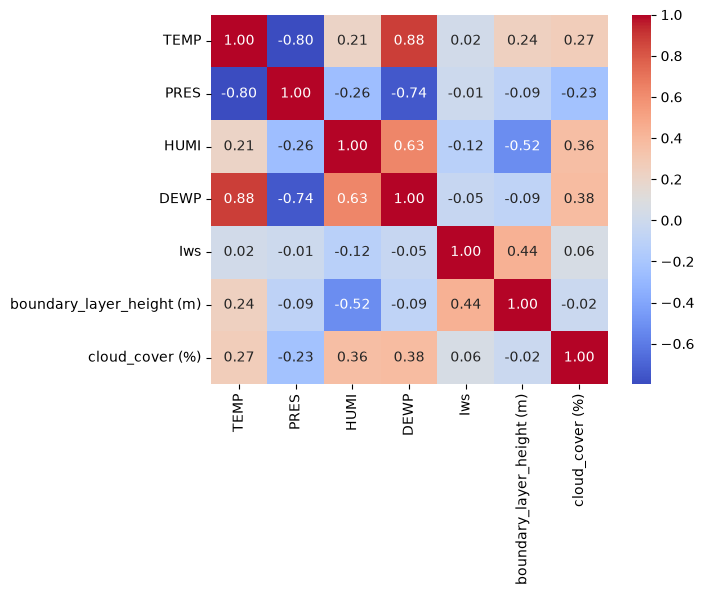

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt
#We are calculating our k-means (different weather regimes) over all cities, else we would not be able to compare the weather regimes
# Korrelation berechnen
#ALL_FEATURES = WEATHER_FEATURES + WIND_DIRECTION #We just want the weather for now 
corr_matrix = df_clean[WEATHER_FEATURES].corr()

# Als Heatmap anzeigen
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

In [76]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Schritt 1: Daten standardisieren (Zwingend erforderlich für PCA & K-Means!)
scaler = StandardScaler()
wetter_scaled = scaler.fit_transform(df_clean[WEATHER_FEATURES].dropna())

# Schritt 2: PCA anwenden (z.B. Reduktion auf die 3 wichtigsten, unkorrelierten Komponenten)
pca = PCA(n_components=3)
wetter_pca = pca.fit_transform(wetter_scaled)

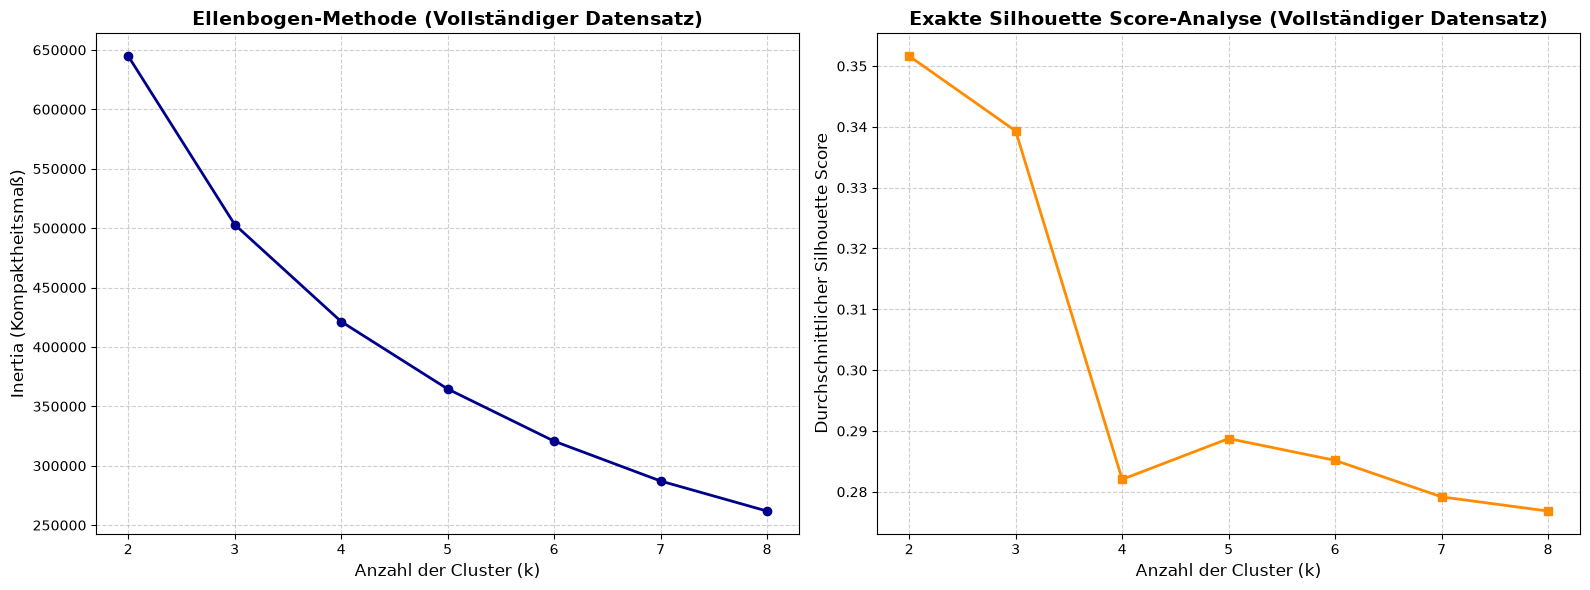

In [77]:
from sklearn.metrics import silhouette_score
# 1. Parameter definieren (Gesamter Datensatz)
k_range = range(2, 9)
inertia_values = []
silhouette_scores = []

# 2. Schleife über alle k (Nutzt die vollen 40.000 Zeilen ohne Sampling)
for k in k_range:
    # K-Means Modell initialisieren und fitten
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(wetter_pca)
    
    # Werte für die Diagramme speichern
    inertia_values.append(kmeans.inertia_)
    
    # Berechnet den exakten Score über alle Zeilen (nutzt ca. 12 GB RAM)
    score = silhouette_score(wetter_pca, labels)
    silhouette_scores.append(score)

# 3. Diagramme nebeneinander ausgeben
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Diagramm 1: Ellenbogen-Methode (Inertia)
ax1.plot(k_range, inertia_values, marker='o', color='darkblue', linewidth=2)
ax1.set_title('Ellenbogen-Methode (Vollständiger Datensatz)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Anzahl der Cluster (k)', fontsize=12)
ax1.set_ylabel('Inertia (Kompaktheitsmaß)', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.set_xticks(k_range)

# Diagramm 2: Exakter Silhouette Score
ax2.plot(k_range, silhouette_scores, marker='s', color='darkorange', linewidth=2)
ax2.set_title('Exakte Silhouette Score-Analyse (Vollständiger Datensatz)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Anzahl der Cluster (k)', fontsize=12)
ax2.set_ylabel('Durchschnittlicher Silhouette Score', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.set_xticks(k_range)

plt.tight_layout()
plt.show()

In [92]:
# Schritt 3: K-Means auf den PCA-Komponenten ausführen
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(wetter_pca)

In [93]:
import pandas as pd

# Ermittelt die Gewichtung der originalen Features pro Hauptkomponente
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=['PC1', 'PC2', 'PC3'], 
    index=WEATHER_FEATURES
)
print("Einzigartige Sinus-Werte:", df_clean['wind_sin'].nunique())
print("Einzigartige Kosinus-Werte:", df_clean['wind_cos'].nunique())
print(loadings)

Einzigartige Sinus-Werte: 318
Einzigartige Kosinus-Werte: 318
                                PC1       PC2       PC3
TEMP                       0.500129  0.265530 -0.251976
PRES                      -0.477803 -0.186120  0.259911
HUMI                       0.351027 -0.445946  0.316934
DEWP                       0.558750 -0.010857 -0.052405
Iws                       -0.028384  0.471572  0.593080
boundary_layer_height (m) -0.044090  0.686010  0.015851
cloud_cover (%)            0.288799 -0.053642  0.643246


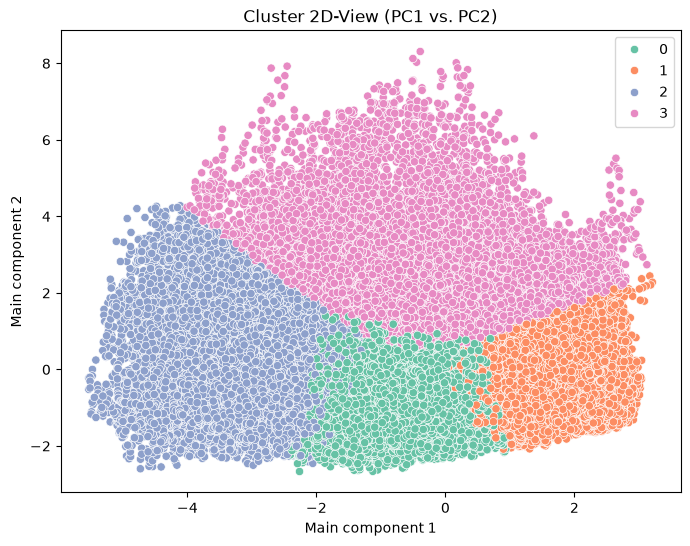

In [94]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=wetter_pca[:, 0], 
    y=wetter_pca[:, 1], 
    hue=clusters, 
    palette='Set2'
)
plt.title('Cluster 2D-View (PC1 vs. PC2)')
plt.xlabel('Main component 1')
plt.ylabel('Main component 2')
plt.show()

175993
Length plot_df  175993


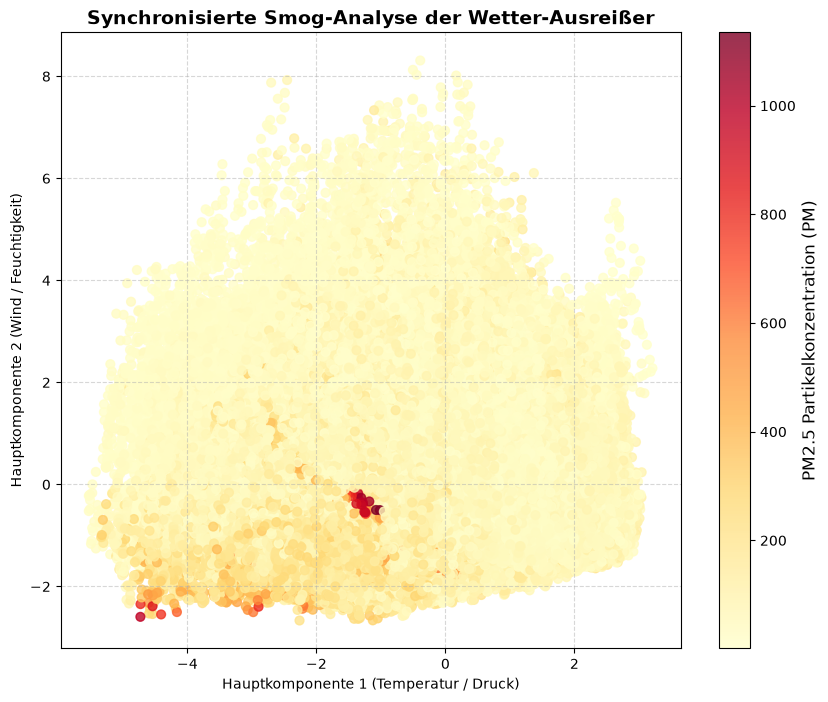

In [95]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Wir holen uns die originalen Indizes der gefilterten Wetterdaten zurück
# (Damit die Zeilen aus der PCA exakt zu den Zeilen im beijing_df passen)
wetter_daten_index = df_clean[["HUMI", "TEMP", "DEWP", "Iws", "PRES", "wind_sin", "wind_cos"]].dropna().index

# 2. Erstellen Sie einen temporären Plot-DataFrame, der absolut synchron ist
#MAYOR ISSUE: PM IS AVERAGED OVER ALL STATIONS OF ONE CITY
plot_df = pd.DataFrame({
    'PC1': wetter_pca[:, 0],
    'PC2': wetter_pca[:, 1],
    'PM25': df_clean.loc[wetter_daten_index, 'PM']
})
print(len(df_clean))
print('Length plot_df ', len(plot_df))
# 3. Jetzt schmeißen wir Zeilen raus, bei denen der Schadstoffwert PM2.5 fehlt
plot_df = plot_df.dropna(subset=['PM25'])

# 4. Jetzt sind X, Y und die Farbe garantiert exakt gleich lang!
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    x=plot_df['PC1'],
    y=plot_df['PC2'],
    c=plot_df['PM25'], # Farb-Vektor hat jetzt exakt die gleiche Länge wie PC1 und PC2
    cmap='YlOrRd',
    s=40,
    alpha=0.8
)

# Farbskala hinzufügen
cbar = plt.colorbar(scatter)
cbar.set_label('PM2.5 Partikelkonzentration (PM)', fontsize=12)

plt.title('Synchronisierte Smog-Analyse der Wetter-Ausreißer', fontsize=14, fontweight='bold')
plt.xlabel('Hauptkomponente 1 (Temperatur / Druck)')
plt.ylabel('Hauptkomponente 2 (Wind / Feuchtigkeit)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [96]:
# KORREKTUR: Die IDs direkt dem Haupt-DataFrame zuweisen (beide haben exakt 51.765 Zeilen)
df_clean['Cluster'] = clusters
print('Length df_clean ', len(df_clean))

# Spalten definieren, für die wir das Profil berechnen wollen
# (Nutzen Sie hier Ihre aktuellen, neuen Features!)
wetter_spalten_aktuell = ["TEMP", "PRES", "HUMI", "DEWP", "Iws", "precipitation", "PM"]

# Erst JETZT filtern wir die Spalten heraus und entfernen eventuelle NaNs (z.B. bei PM)
analyse_df = df_clean[wetter_spalten_aktuell + ['Cluster']].dropna().copy()
print('Length analyse_df ', len(analyse_df))

# 3. Berechnen Sie den Mittelwert für jede Wettergröße pro Cluster
cluster_profile = analyse_df.groupby('Cluster').mean()
print('Length cluster_profile ', len(cluster_profile))
# Ausgabe der Tabelle im Notebook
print("── REALE PROFIL-MITTELWERTE PRO CLUSTER ──────────────────────────────────")
print(cluster_profile.round(2))

Length df_clean  175993
Length analyse_df  175993
Length cluster_profile  4
── REALE PROFIL-MITTELWERTE PRO CLUSTER ──────────────────────────────────
          TEMP     PRES   HUMI   DEWP    Iws  precipitation     PM
Cluster                                                           
0        10.08  1020.44  74.47   5.40   8.87           0.06  95.33
1        23.97  1007.49  80.53  20.15   8.13           0.24  60.00
2        -0.44  1026.55  43.47 -12.45   9.05           0.00  85.04
3        22.81  1011.24  44.75   8.83  14.70           0.04  55.50


── ABSOLUTE STUNDEN PRO STADT UND CLUSTER (SORTIERT) ──────────────────
Cluster        0      1      2     3
city                                
Beijing    11249  12865  17095  9632
Shenyang    5792   5614   8662  6017
Shanghai   13219  13298   2747  5659
Chengdu    12387  14190   1127  2934
Guangzhou   7272  21410    745  4079

── PROZENTUALE VERTEILUNG PRO STADT (ZEILENSUMME = 100%) ──────────────
Cluster       0     1     2     3
city                             
Beijing    22.1  25.3  33.6  18.9
Shenyang   22.2  21.5  33.2  23.1
Shanghai   37.9  38.1   7.9  16.2
Chengdu    40.4  46.3   3.7   9.6
Guangzhou  21.7  63.9   2.2  12.2


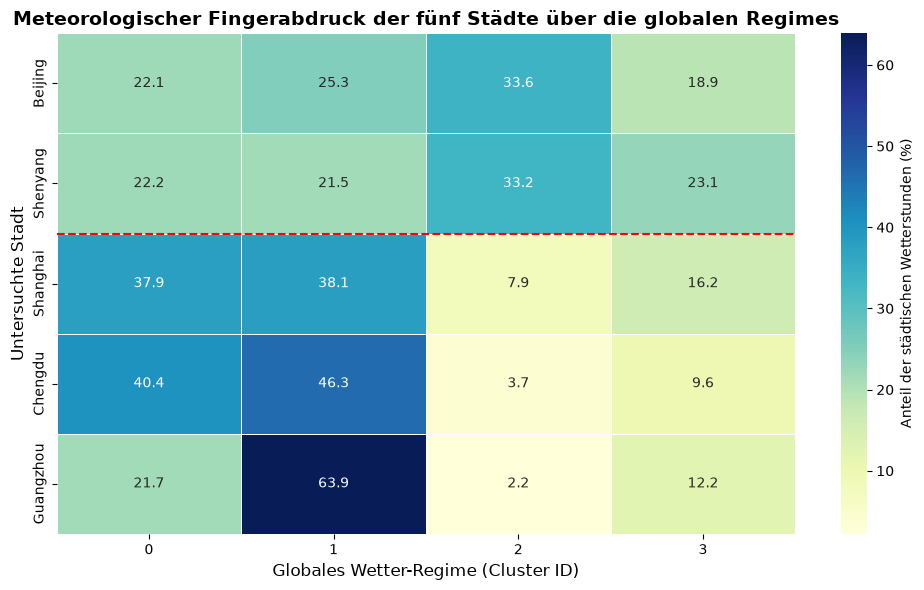

In [97]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Absolute Häufigkeiten berechnen (Stunden pro Stadt und Cluster)
crosstab_abs = pd.crosstab(df_clean['city'], df_clean['Cluster'])

# 2. In Prozent pro Stadt umrechnen (Zeilensumme = 100%)
crosstab_pct = pd.crosstab(df_clean['city'], df_clean['Cluster'], normalize='index') * 100

# ── NEU: Explizite Reihenfolge festlegen (Nordstädte zuerst, dann Südstädte) ──
wunsch_reihenfolge = ["Beijing", "Shenyang", "Shanghai", "Chengdu", "Guangzhou"]
crosstab_pct = crosstab_pct.reindex(wunsch_reihenfolge)
crosstab_abs = crosstab_abs.reindex(wunsch_reihenfolge)

print("── ABSOLUTE STUNDEN PRO STADT UND CLUSTER (SORTIERT) ──────────────────")
print(crosstab_abs)
print("\n── PROZENTUALE VERTEILUNG PRO STADT (ZEILENSUMME = 100%) ──────────────")
print(crosstab_pct.round(1))

# 3. Wissenschaftliche Heatmap zeichnen
plt.figure(figsize=(10, 6))
sns.heatmap(
    crosstab_pct, 
    annot=True,          # Zahlen in den Kästchen anzeigen
    fmt=".1f",          # Eine Nachkommastelle
    cmap="YlGnBu",       # Wissenschaftliche Farbpalette
    cbar_kws={'label': 'Anteil der städtischen Wetterstunden (%)'},
    linewidths=0.5
)

# Optischer Trenner im Plot: Eine horizontale Linie zwischen Nord- und Südstädten
# Da Beijing und Shenyang die ersten beiden Zeilen (Index 0 und 1) sind, ziehen wir die Linie bei y=2
plt.axhline(y=2, color='red', linestyle='--', linewidth=1.5, label='Nord/Süd-Grenze (Heating Zone)')

plt.title("Meteorologischer Fingerabdruck der fünf Städte über die globalen Regimes", fontsize=14, fontweight='bold')
plt.xlabel("Globales Wetter-Regime (Cluster ID)", fontsize=12)
plt.ylabel("Untersuchte Stadt", fontsize=12)
plt.tight_layout()
plt.show()

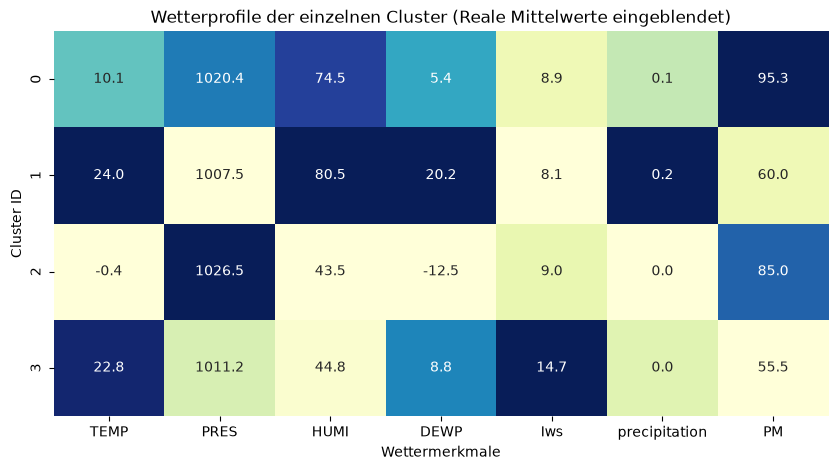

In [98]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Wir normalisieren die Mittelwerte kurz auf eine Skala von 0 bis 1, 
# damit wir Temperatur und Luftdruck in derselben Heatmap fair vergleichen können.
scaler_plot = MinMaxScaler()
cluster_profile_scaled = pd.DataFrame(
    scaler_plot.fit_transform(cluster_profile),
    columns=cluster_profile.columns,
    index=cluster_profile.index
)

# Heatmap zeichnen
plt.figure(figsize=(10, 5))
sns.heatmap(cluster_profile_scaled, annot=cluster_profile, fmt=".1f", cmap="YlGnBu", cbar=False)
plt.title("Wetterprofile der einzelnen Cluster (Reale Mittelwerte eingeblendet)")
plt.ylabel("Cluster ID")
plt.xlabel("Wettermerkmale")
plt.show()

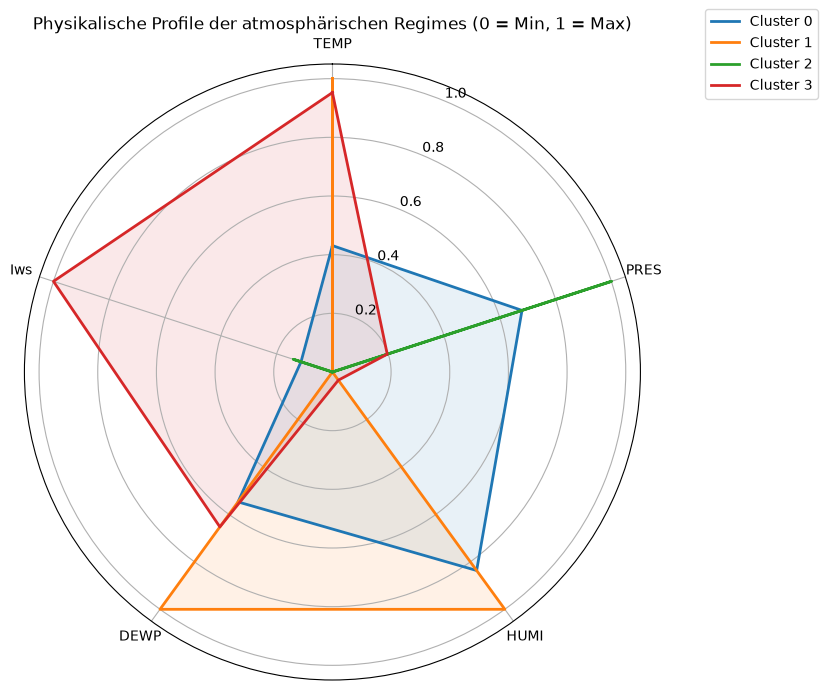

In [99]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# 1. Mittelwerte der echten Features pro Cluster berechnen
# (Stellen Sie sicher, dass 'clusters' die IDs 0 bis 4 enthält)
df_clean['Cluster'] = clusters
features_to_plot = ["TEMP", "PRES", "HUMI", "DEWP", "Iws"]
cluster_means = df_clean.groupby('Cluster')[features_to_plot].mean()

# 2. Daten auf 0-1 skalieren, damit sie im Netzdiagramm vergleichbar sind
scaler = MinMaxScaler()
cluster_means_scaled = scaler.fit_transform(cluster_means)

# 3. Radar Chart zeichnen
labels = features_to_plot
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1] # Kreis schließen

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for i in range(len(cluster_means)):
    values = cluster_means_scaled[i].tolist()
    values += values[:1] # Kreis schließen
    ax.plot(angles, values, linewidth=2, label=f'Cluster {i}')
    ax.fill(angles, values, alpha=0.1)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)
plt.title("Physikalische Profile der atmosphärischen Regimes (0 = Min, 1 = Max)")
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

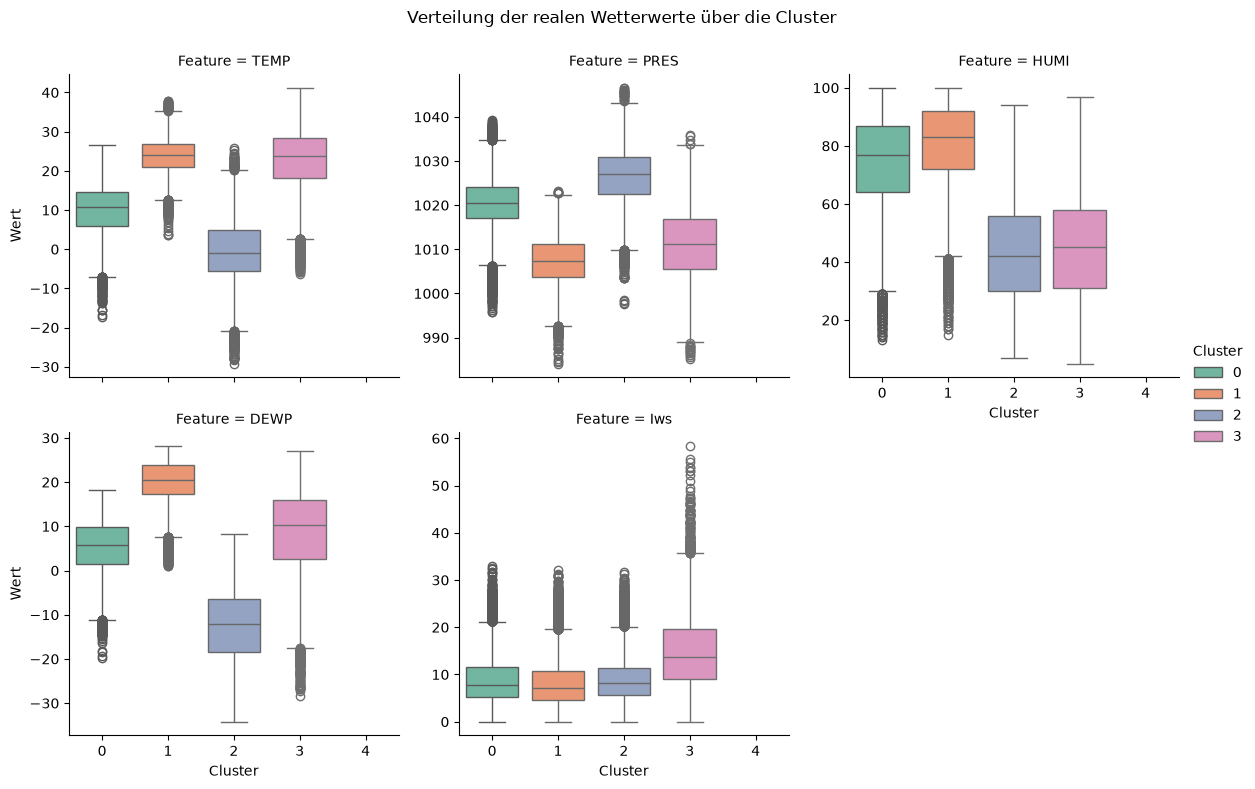

In [100]:
import seaborn as sns

# Schmilzt das DataFrame für Seaborn FacetGrid
df_melt = df_clean.melt(id_vars=['Cluster'], value_vars=features_to_plot, 
                        var_name='Feature', value_name='Wert')

g = sns.FacetGrid(df_melt, col="Feature", hue="Cluster", col_wrap=3, sharey=False, height=4, palette='Set2')
g.map(sns.boxplot, "Cluster", "Wert", order=[0,1,2,3,4])
g.add_legend()
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Verteilung der realen Wetterwerte über die Cluster')
plt.show()

In [101]:
# 1. Wir filtern die Spalten für die Smog-Analyse (reine Originalwerte)
# Ersetzen Sie 'PM' durch Ihren exakten Spaltennamen (z.B. 'PM_Dongsi' oder 'PM')
pm_feature = 'PM'  

# 2. Berechnen Sie die wichtigsten ökonomischen Kennzahlen pro Cluster
pm_analyse = df_clean.groupby('Cluster')[pm_feature].agg(
    Anzahl_Stunden='count',
    Durchschnitt_PM25='mean',
    Median_PM25='median',
    Maximal_PM25='max'
).round(2)

print("── PM2.5 BELASTUNG PRO ATMOSPHÄRISCHEM REGIME ──────────────────────────")
print(pm_analyse)

── PM2.5 BELASTUNG PRO ATMOSPHÄRISCHEM REGIME ──────────────────────────
         Anzahl_Stunden  Durchschnitt_PM25  Median_PM25  Maximal_PM25
Cluster                                                              
0                 49919              95.33        72.00       1134.67
1                 67377              60.00        47.00        512.00
2                 30376              85.04        58.67       1065.50
3                 28321              55.50        41.25        761.00


C:\Users\olive\AppData\Local\Temp\ipykernel_30876\945984710.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


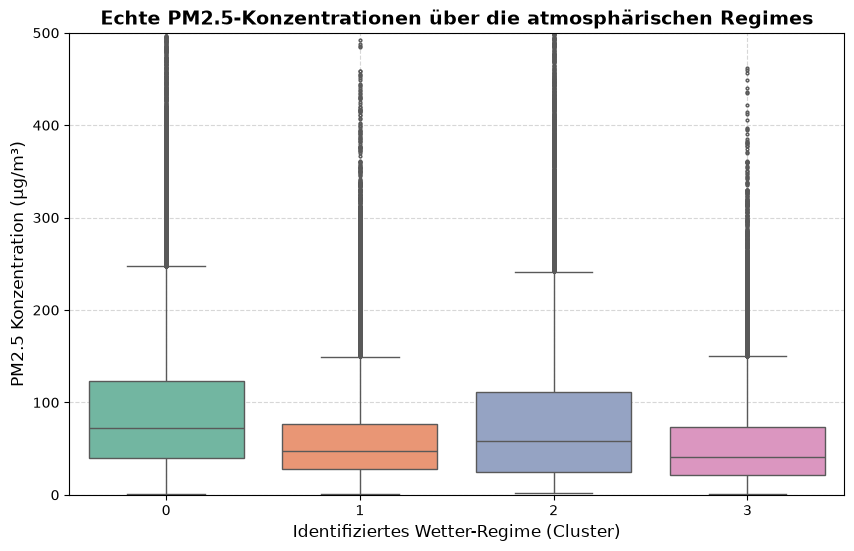

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Boxplot der unskalierten PM2.5-Werte pro Cluster
sns.boxplot(
    data=df_clean,
    x='Cluster',
    y=pm_feature,
    palette='Set2',
    fliersize=2  # Macht die Ausreißer-Punkte kleiner und übersichtlicher
)

# Ökonomisch sinnvolle Begrenzung der Y-Achse (z.B. bis 500 μg/m³), damit der Kasten lesbar bleibt
plt.ylim(0, 500) 

plt.title('Echte PM2.5-Konzentrationen über die atmosphärischen Regimes', fontsize=14, fontweight='bold')
plt.xlabel('Identifiziertes Wetter-Regime (Cluster)', fontsize=12)
plt.ylabel('PM2.5 Konzentration (µg/m³)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [106]:
# 3. Schritt: Vollständige PCA fitten (7 Komponenten für alle 7 Variablen)
# Das ist notwendig, um die maximale Gesamtvarianz zu berechnen
pca_full = PCA(n_components=len(WEATHER_FEATURES))
pca_full.fit(wetter_scaled)

# 4. Schritt: Ergebnisse übersichtlich anzeigen
print("── ERKLÄRTE VARIANZ PRO HAUPTKOMPONENTE (PCA) ──────────────────────────")
for i, var in enumerate(pca_full.explained_variance_ratio_):
    print(f"Hauptkomponente {i+1} (PC{i+1}) erklärt: {var*100:.1f}% der Varianz")

print("\n── KUMULIERTE (AUFSUMMIERTE) INFORMATIONSABDECKUNG ────────────────────")
cum_var_2 = np.sum(pca_full.explained_variance_ratio_[:2]) * 100
cum_var_3 = np.sum(pca_full.explained_variance_ratio_[:3]) * 100
cum_var_4 = np.sum(pca_full.explained_variance_ratio_[:4]) * 100

print(f"➡ Mit n=2 Komponenten (PC1 + PC2) decken Sie {cum_var_2:.1f}% der Wetter-Information ab.")
print(f"➡ Mit n=3 Komponenten (PC1 + PC2 + PC3) decken Sie {cum_var_3:.1f}% der Wetter-Information ab.")
print(f"➡ Mit n=4 Komponenten (PC1 + PC2 + PC3 + PC4) decken Sie {cum_var_4:.1f}% der Wetter-Information ab.")

── ERKLÄRTE VARIANZ PRO HAUPTKOMPONENTE (PCA) ──────────────────────────
Hauptkomponente 1 (PC1) erklärt: 43.3% der Varianz
Hauptkomponente 2 (PC2) erklärt: 25.1% der Varianz
Hauptkomponente 3 (PC3) erklärt: 14.3% der Varianz
Hauptkomponente 4 (PC4) erklärt: 9.7% der Varianz
Hauptkomponente 5 (PC5) erklärt: 4.6% der Varianz
Hauptkomponente 6 (PC6) erklärt: 2.9% der Varianz
Hauptkomponente 7 (PC7) erklärt: 0.1% der Varianz

── KUMULIERTE (AUFSUMMIERTE) INFORMATIONSABDECKUNG ────────────────────
➡ Mit n=2 Komponenten (PC1 + PC2) decken Sie 68.4% der Wetter-Information ab.
➡ Mit n=3 Komponenten (PC1 + PC2 + PC3) decken Sie 82.7% der Wetter-Information ab.
➡ Mit n=4 Komponenten (PC1 + PC2 + PC3 + PC4) decken Sie 92.4% der Wetter-Information ab.


In [111]:
import scipy.stats as stats
from scikit_posthocs import posthoc_dunn

# 1. Kruskal-Wallis-Test über alle 4 Cluster hinweg
# Ersetzen Sie 'PM_Dongsi' durch Ihren exakten PM2.5-Spaltennamen
cluster_groups = [df_clean[df_clean['Cluster'] == i]['PM'].dropna() for i in range(4)]
kw_stat, kw_p = stats.kruskal(*cluster_groups)

print("── KRUSKAL-WALLIS-TEST (GLOBAL) ────────────────────────────────────────")
print(f"H-Statistik: {kw_stat:.2f}")
print(f"p-Wert:      {kw_p:.4e} (Ein Wert < 0.01 bedeutet hochsignifikante Unterschiede)")

# 2. Dunn-Test für den paarweisen Vergleich (Welches Cluster unterscheidet sich von welchem?)
if kw_p < 0.05:
    print("\n── DUNN-TEST (PAARWEISER VERGLEICH DER VERTRAUENSINTERVALLE) ───────────")
    dunn_matrix = posthoc_dunn(df_clean, val_col='PM', group_col='Cluster', p_adjust='bonferroni')
    print(dunn_matrix.round(4))

── KRUSKAL-WALLIS-TEST (GLOBAL) ────────────────────────────────────────
H-Statistik: 10009.90
p-Wert:      0.0000e+00 (Ein Wert < 0.01 bedeutet hochsignifikante Unterschiede)

── DUNN-TEST (PAARWEISER VERGLEICH DER VERTRAUENSINTERVALLE) ───────────
     0    1    2    3
0  1.0  0.0  0.0  0.0
1  0.0  1.0  0.0  0.0
2  0.0  0.0  1.0  0.0
3  0.0  0.0  0.0  1.0


In [113]:
# Wichtige Verteilungskennzahlen pro Cluster berechnen
target_separation_table = df_clean.groupby('Cluster')['PM'].agg(
    Beobachtungen='count',
    Mittelwert='mean',
    Median='median',
    Standardabweichung='std',
    Perzentil_75=lambda x: x.quantile(0.75),
    Maximum='max'
).round(1)

print("── TARGET SEPARATION MATRIX FOR PM2.5 ──────────────────────────────────")
print(target_separation_table)

── TARGET SEPARATION MATRIX FOR PM2.5 ──────────────────────────────────
         Beobachtungen  Mittelwert  Median  Standardabweichung  Perzentil_75  \
Cluster                                                                        
0                49919        95.3    72.0                80.9         123.3   
1                67377        60.0    47.0                47.9          76.7   
2                30376        85.0    58.7                87.5         111.7   
3                28321        55.5    41.2                49.5          73.0   

         Maximum  
Cluster           
0         1134.7  
1          512.0  
2         1065.5  
3          761.0  
